In [2]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import time

# Add parent directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

from OptLinearRegress import LinearRegressor

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Imported package successfully


Rank: None, Noise: 0 | Custom R2: 1.0000 | Sklearn R2: 1.0000
Rank: None, Noise: 5 | Custom R2: 0.9990 | Sklearn R2: 0.9990
Rank: None, Noise: 10 | Custom R2: 0.9958 | Sklearn R2: 0.9958
Rank: None, Noise: 25 | Custom R2: 0.9746 | Sklearn R2: 0.9746
Rank: None, Noise: 50 | Custom R2: 0.9058 | Sklearn R2: 0.9058
Rank: None, Noise: 100 | Custom R2: 0.7064 | Sklearn R2: 0.7064
Rank: 5, Noise: 0 | Custom R2: 1.0000 | Sklearn R2: 1.0000
Rank: 5, Noise: 5 | Custom R2: 0.0906 | Sklearn R2: 0.0913
Rank: 5, Noise: 10 | Custom R2: 0.0221 | Sklearn R2: 0.0229
Rank: 5, Noise: 25 | Custom R2: -0.0005 | Sklearn R2: 0.0002
Rank: 5, Noise: 50 | Custom R2: -0.0044 | Sklearn R2: -0.0037
Rank: 5, Noise: 100 | Custom R2: -0.0057 | Sklearn R2: -0.0049
Rank: 10, Noise: 0 | Custom R2: 1.0000 | Sklearn R2: 1.0000
Rank: 10, Noise: 5 | Custom R2: 0.1310 | Sklearn R2: 0.1316
Rank: 10, Noise: 10 | Custom R2: 0.0348 | Sklearn R2: 0.0355
Rank: 10, Noise: 25 | Custom R2: 0.0020 | Sklearn R2: 0.0027
Rank: 10, Noise: 

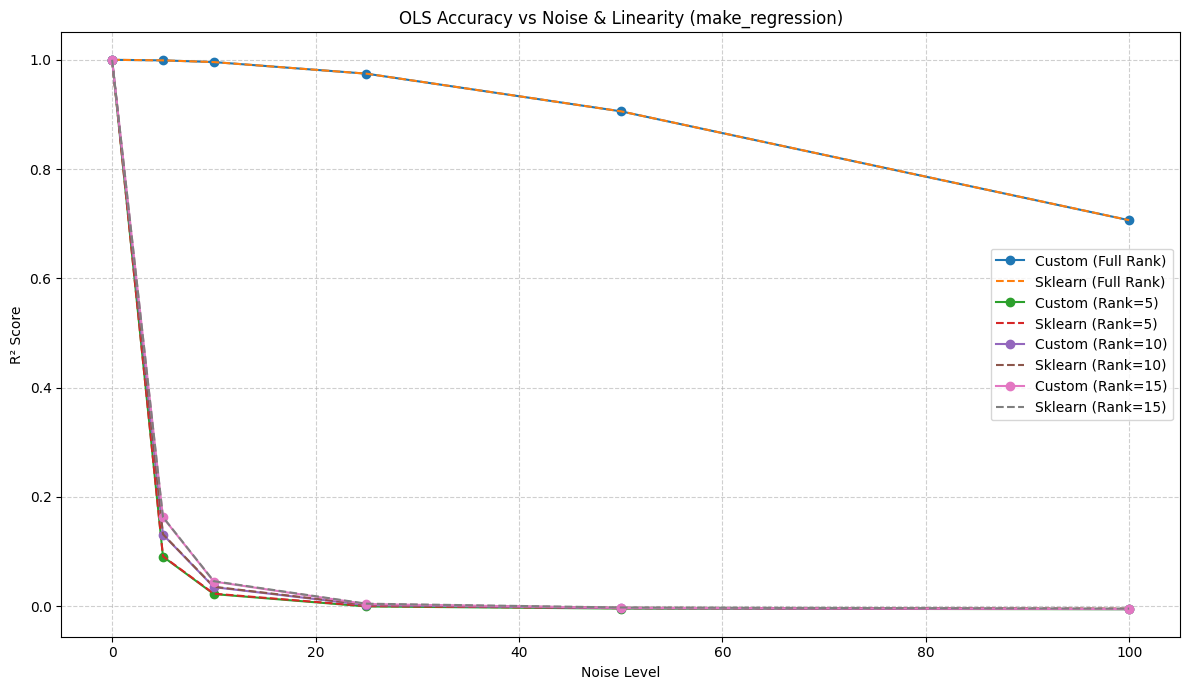


Toy Dataset Metrics:
{'Custom': {'R2': 0.03912152174442829, 'MSE': 398.1652772918042, 'RMSE': np.float64(19.954079214331195), 'MAE': 15.970102112389593}, 'Sklearn': {'R2': 0.0365979952612111, 'MSE': 399.21096688177977, 'RMSE': np.float64(19.980264434731083), 'MAE': 15.986059144343193}}


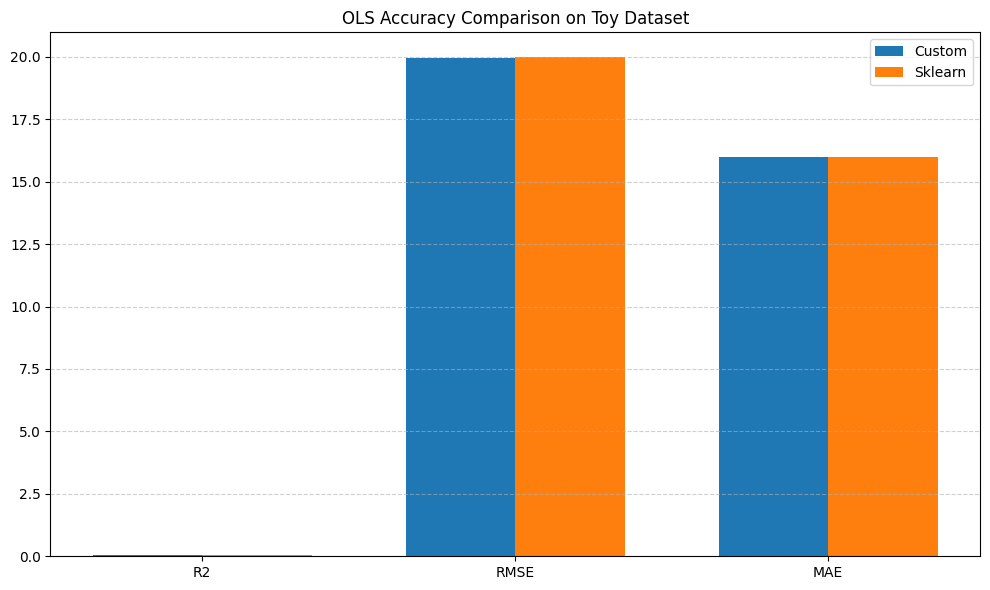

In [4]:
# ==============================
# Evaluation Utility
# ==============================

def evaluate_models(X, y, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    # ===== Custom OLS =====
    model_custom = LinearRegressor()
    model_custom.fit(X_train.tolist(), y_train.tolist())

    # If predict exists → use it
    if hasattr(model_custom, "predict"):
        y_pred_custom = model_custom.predict(X_test.tolist())
    else:
        # Otherwise compute manually using learned coefficients
        coef = model_custom.coef_ if hasattr(model_custom, "coef_") else model_custom.weights
        y_pred_custom = np.dot(X_test, np.array(coef))

    # ===== Sklearn OLS =====
    model_sklearn = LinearRegression(fit_intercept=False)
    model_sklearn.fit(X_train, y_train)
    y_pred_sklearn = model_sklearn.predict(X_test)

    metrics = {}

    for name, y_pred in {
        "Custom": y_pred_custom,
        "Sklearn": y_pred_sklearn,
    }.items():
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)

        metrics[name] = {
            "R2": r2,
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae
        }

    return metrics


# make_regression Experiment

def experiment_make_regression():
    n_samples = 5000
    n_features = 20

    noise_levels = [0, 5, 10, 25, 50, 100]
    effective_ranks = [None, 5, 10, 15]  # controls linearity/collinearity

    results = {}

    for rank in effective_ranks:
        custom_r2 = []
        sklearn_r2 = []

        for noise in noise_levels:
            X, y = make_regression(
                n_samples=n_samples,
                n_features=n_features,
                noise=noise,
                effective_rank=rank,
                random_state=42
            )

            metrics = evaluate_models(X, y)

            custom_r2.append(metrics["Custom"]["R2"])
            sklearn_r2.append(metrics["Sklearn"]["R2"])

            print(
                f"Rank: {rank}, Noise: {noise} | "
                f"Custom R2: {metrics['Custom']['R2']:.4f} | "
                f"Sklearn R2: {metrics['Sklearn']['R2']:.4f}"
            )

        results[rank] = (noise_levels, custom_r2, sklearn_r2)

    return results


def plot_make_regression(results):
    plt.figure(figsize=(12, 7))

    for rank, (noise, custom_r2, sklearn_r2) in results.items():
        label_rank = f"Rank={rank}" if rank else "Full Rank"

        plt.plot(noise, custom_r2, marker='o',
                 label=f'Custom ({label_rank})')
        plt.plot(noise, sklearn_r2, linestyle='--',
                 label=f'Sklearn ({label_rank})')

    plt.xlabel("Noise Level")
    plt.ylabel("R² Score")
    plt.title("OLS Accuracy vs Noise & Linearity (make_regression)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig("OLS_accuracy_test-03-03-26_1.png", dpi=600)
    plt.show()


# Toy Dataset Experiment

def toy_dataset():
    """
    Slightly non-ideal real-world style regression:
    - moderate multicollinearity
    - moderate noise
    """
    X, y = make_regression(
        n_samples=1000,
        n_features=5,
        noise=20,
        effective_rank=3,
        random_state=1
    )

    return X, y


def plot_toy_results(metrics):
    labels = ["R2", "RMSE", "MAE"]
    custom_vals = [
        metrics["Custom"]["R2"],
        metrics["Custom"]["RMSE"],
        metrics["Custom"]["MAE"]
    ]
    sklearn_vals = [
        metrics["Sklearn"]["R2"],
        metrics["Sklearn"]["RMSE"],
        metrics["Sklearn"]["MAE"]
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 6))
    plt.bar(x - width/2, custom_vals, width, label='Custom')
    plt.bar(x + width/2, sklearn_vals, width, label='Sklearn')

    plt.xticks(x, labels)
    plt.title("OLS Accuracy Comparison on Toy Dataset")
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()

    plt.savefig("OLS_accuracy_test-03-03-26_2.png", dpi=600)
    plt.show()


# ==============================
# Run Experiments
# ==============================

# make_regression experiment
results = experiment_make_regression()
plot_make_regression(results)

# Toy dataset test
X_toy, y_toy = toy_dataset()
toy_metrics = evaluate_models(X_toy, y_toy)

print("\nToy Dataset Metrics:")
print(toy_metrics)

plot_toy_results(toy_metrics)